# GANs

## Start with the problem: learn a sampler using an opponent's feedback

Suppose we want a network to generate measurements resembling examples from a source distribution. We can generate a value from random input, but need a training signal that says how the generated distribution differs from the real one.

A **generative adversarial network (GAN)** uses two learned networks. A generator maps random input to a sample. A discriminator receives real or generated samples and scores whether they came from the real source. The generator learns through the discriminator's response.

The two objectives change together during training. A discriminator becomes more capable at distinguishing current samples; a generator changes what the discriminator must distinguish. This is different from fitting one fixed target function with an ordinary supervised loss.

We will calculate both losses, follow their gradients, inspect alternating updates, and separate distributional quality from loss values. The [code companion](39_GANs.ipynb) trains a tiny one-dimensional pair against a Gaussian target. Its short run is a mechanics demonstration, not a successful-generation claim. [Generative Modeling Foundations](37_Generative_Modeling_Foundations_Notes.ipynb) explains the distribution view.


## Follow the two sample paths

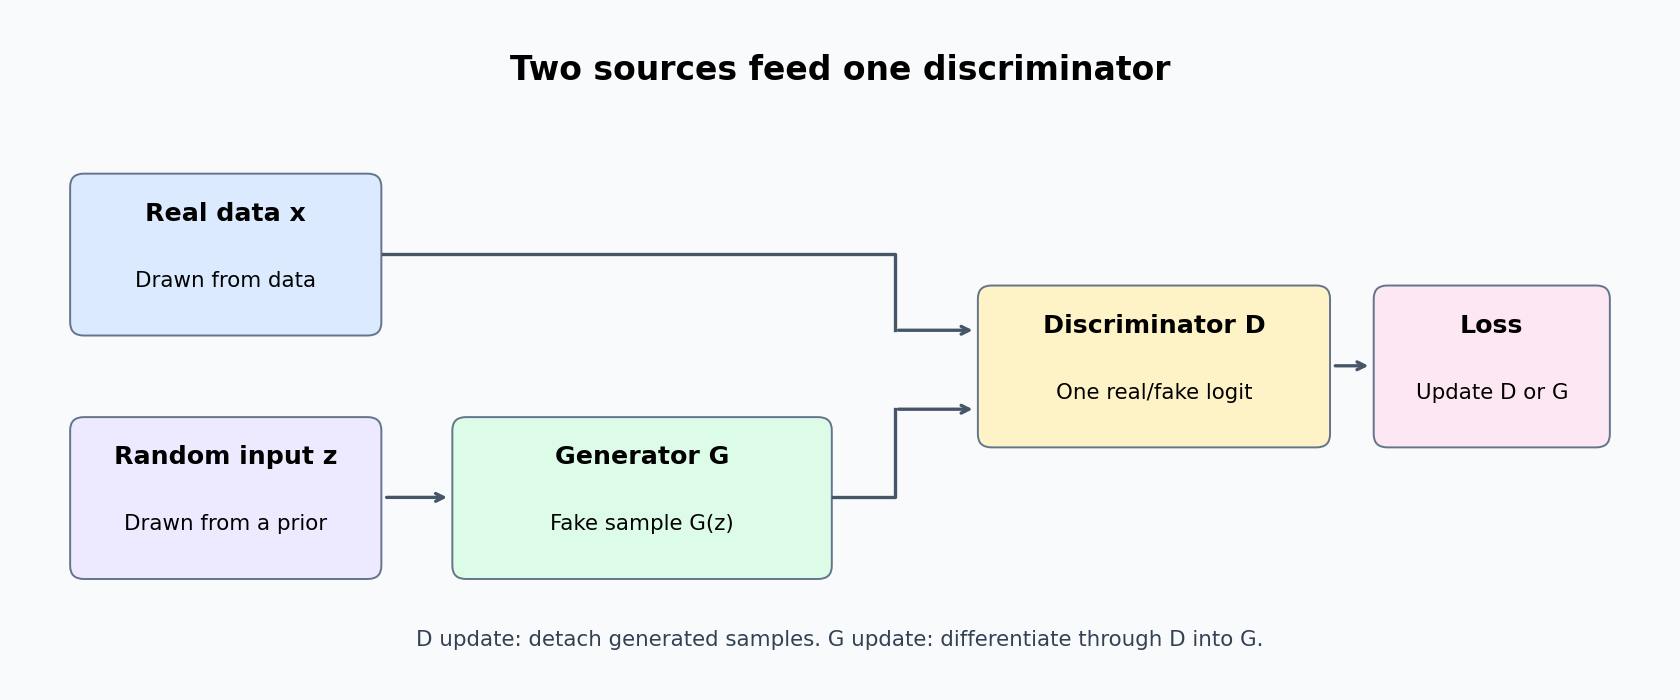

Let noise $z$ come from a prior such as $\mathcal N(0,I)$. The generator produces $\tilde x=G_\theta(z)$. The discriminator produces a logit $s_\psi(x)$; sigmoid converts it to $D_\psi(x)$ for probability-style interpretation.

| Network | Input | Output | Updated to do what? |
| --- | --- | --- | --- |
| Generator | Random latent input | Generated observation | Obtain favorable discriminator responses |
| Discriminator | Real or generated observation | One real/fake score | Distinguish the two current sources |

The discriminator is a binary classifier inside the training system, not a separate proof of authenticity. Its labels indicate which source supplied the training observation.

The generator can define an implicit distribution through its sampling path even if no tractable normalized density is calculated for an output. A valid generator output shape therefore says nothing by itself about whether its samples match the source distribution.


## State the discriminator objective and reduction

A common discriminator loss is:

$$L_D=-\mathbb E_{x\sim p_{data}}\ln D(x)-\mathbb E_{z\sim p(z)}\ln(1-D(G(z))).$$

The companion implements one mean binary-logit loss for real examples plus one mean binary-logit loss for fake examples. It does not average the two resulting means again.

For one selected real score $D(x)=0.9$ and one fake score $D(G(z))=0.2$:

| Source | Target label | Probability of real | Loss |
| --- | --- | --- | --- |
| Real | 1 | 0.9 | $-\ln0.9=0.105361$ |
| Fake | 0 | 0.2 | $-\ln0.8=0.223144$ |
| Sum of the two terms | — | — | 0.328504 |

These are chosen probabilities for one snapshot. A different reduction, such as averaging a combined real/fake batch, can differ by a constant factor. The factor affects gradients and should be kept explicit when comparing hand calculations with code.


## Derive discriminator logit gradients

For binary cross-entropy on a logit $s$ with target $y$, the derivative is $\sigma(s)-y$. The selected probabilities correspond to logits $\ln9\approx2.197225$ for the real example and $\ln(0.2/0.8)\approx-1.386294$ for the fake example.

| Example | Probability | Target | Logit gradient |
| --- | --- | --- | --- |
| Real | 0.9 | 1 | -0.1 |
| Fake | 0.2 | 0 | 0.2 |

A gradient-descent update therefore pushes the real score upward and the fake score downward, provided we isolate these scores as adjustable quantities.

The actual discriminator has shared weights. Its weight derivatives combine these logit gradients with sample features, and the contributions from the batch add according to the objective's reduction. The generator should not receive parameter updates from this discriminator objective.

The companion detaches the generated batch during this step. Detaching preserves its numerical values while removing the backward connection into the generator graph.


## Distinguish minimax and non-saturating generator losses

The original adversarial formulation uses a minimax objective; a common practical alternative minimizes:

$$L_G^{NS}=-\mathbb E_z\ln D(G(z)).$$

This **non-saturating** objective treats generated samples as target one for the generator update. The foundational objectives and their motivations are described in the [original GAN paper](https://arxiv.org/abs/1406.2661).

At selected fake probability 0.2, non-saturating loss is $-\ln0.2\approx1.609438$. Its derivative with respect to the discriminator's fake-sample logit is $0.2-1=-0.8$.

The minimax generator term $\ln(1-D(G(z)))$ instead has derivative $-D(G(z))=-0.2$ at that point.

| Fake probability | Minimax logit derivative | Non-saturating logit derivative |
| --- | --- | --- |
| 0.01 | -0.01 | -0.99 |
| 0.20 | -0.20 | -0.80 |
| 0.90 | -0.90 | -0.10 |

When fake samples receive very low probabilities, the non-saturating choice supplies a stronger logit-level gradient. This does not guarantee stable training; the discriminator's input derivatives and the rest of the optimization still matter.


## Alternate two updates rather than minimizing one shared loss

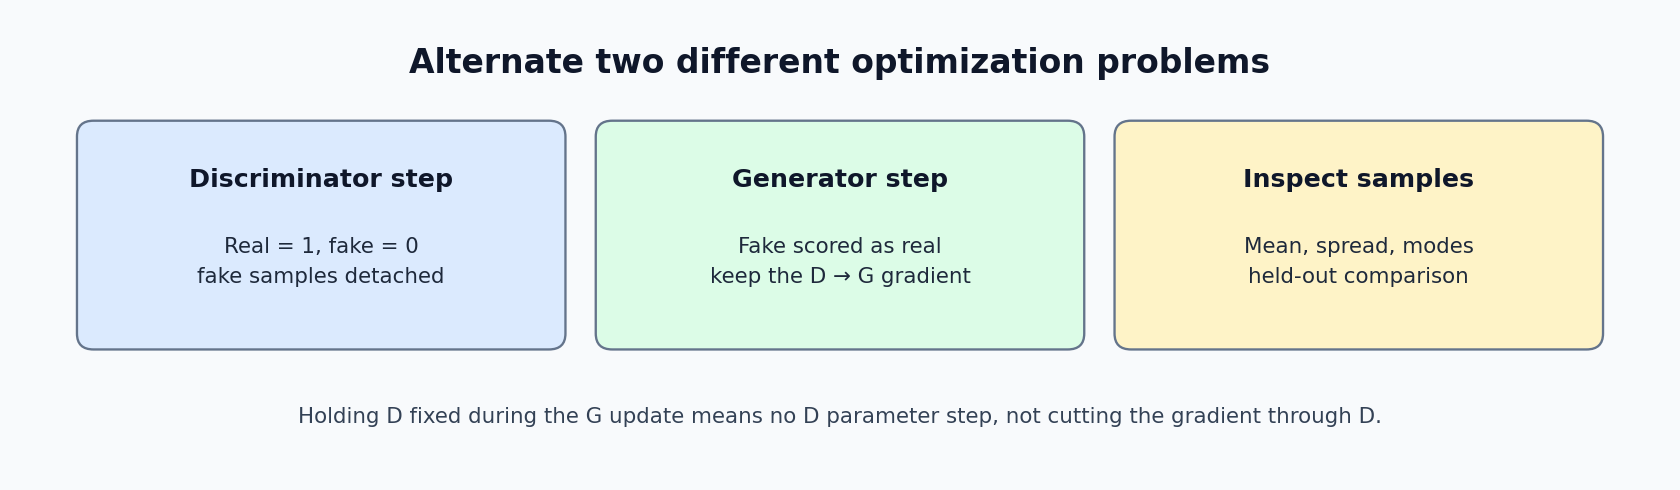

A clear training round is:

1. Draw real observations and random inputs.
2. Generate a fake batch and detach it for the discriminator objective.
3. Clear discriminator gradients, backpropagate its loss, and step its optimizer.
4. Draw random inputs again and generate a differentiable fake batch.
5. Evaluate that batch with the current discriminator using target-one generator loss.
6. Clear generator gradients, backpropagate, and step the generator optimizer.

During the generator step, discriminator parameters are held numerically fixed, but the differentiable transformation through the discriminator is needed to reach the generator. Putting that discriminator call inside a no-gradient block would cut the required path.

It is possible to suppress discriminator parameter-gradient storage during the generator step while retaining derivatives with respect to its input. The companion instead lets those parameter gradients be computed without stepping the discriminator optimizer; they are cleared before its next discriminator backward pass.

“Do not update D here” and “do not differentiate through D” are different instructions.


## Work a complete generator update with a simple opponent

Use scalar generator $G(z)=az+b$, with $a=0.5$, $b=0$, and selected noise $z=1$. The fake observation is 0.5. Let the fixed discriminator logit be $s(x)=2x-1$, giving $s=0$ and $D=0.5$.

For non-saturating generator loss, $L_G=-\ln0.5=0.693147$. The derivatives are:

$$\frac{\partial L_G}{\partial s}=-0.5,\qquad\frac{\partial s}{\partial x}=2,$$
$$\frac{\partial L_G}{\partial x}=-1,\qquad\frac{\partial L_G}{\partial a}=-1,\qquad\frac{\partial L_G}{\partial b}=-1.$$

An SGD update at learning rate 0.1 gives $a=0.6$ and $b=0.1$. The same selected noise now generates 0.7, discriminator logit becomes 0.4, and generator loss decreases to about 0.513015.

This update changes both the generator's location and spread when viewed over its noise distribution. It improves this selected objective against this fixed opponent, but it is not proof that the target distribution has been learned. The companion uses nonlinear networks and Adam rather than this selected linear/SGD calculation.


## Understand the discriminator's ideal reference behavior

For a fixed generator and the classical binary objective, an ideal discriminator under suitable assumptions has:

$$D^*(x)=\frac{p_{data}(x)}{p_{data}(x)+p_G(x)}.$$

At a location where real density is 0.3 and generated density is 0.1, this value is 0.75. Where real density is 0.2 and generated density is 0.4, it is one third.

If the two distributions match, the ideal discriminator outputs 0.5 where their common density is positive. Under the companion's sum-of-means reduction, this reference gives $L_D=2\ln2\approx1.386294$ and non-saturating $L_G=\ln2\approx0.693147$.

A poorly trained discriminator can also output 0.5 while the distributions differ drastically. These values describe an ideal reference situation, not a universal stopping criterion.

An observed discriminator loss changes with both players. It cannot be interpreted like a fixed supervised test loss without considering what the generator and discriminator are currently doing.


## Trace the companion's exact networks and shapes

The companion's target is a one-dimensional Gaussian with mean two and standard deviation one. Each training round draws 64 fresh real values and 64 standard-normal random inputs.

| Network stage | Shape | Parameters |
| --- | --- | --- |
| Generator input | $(64,1)$ | None |
| Linear $1\to16$ | $(64,16)$ | 32 |
| Tanh | $(64,16)$ | None |
| Linear $16\to1$ | $(64,1)$ | 17 |
| Discriminator linear $1\to16$ | $(64,16)$ | 32 |
| LeakyReLU, slope 0.2 | $(64,16)$ | None |
| Discriminator linear $16\to1$ | $(64,1)$ | 17 |

Each network has 49 parameters, totaling 98. The generator's final layer has no tanh, so generated observations are not restricted to $[-1,1]$ by its intermediate activation.

The training loop runs 100 rounds with separate Adam optimizers at learning rate 0.01. It then draws 256 fresh random inputs and reports their generated mean. The finite-loss and output-shape assertions do not require that this mean or variance match the target.


## Separate location, spread, and mode coverage

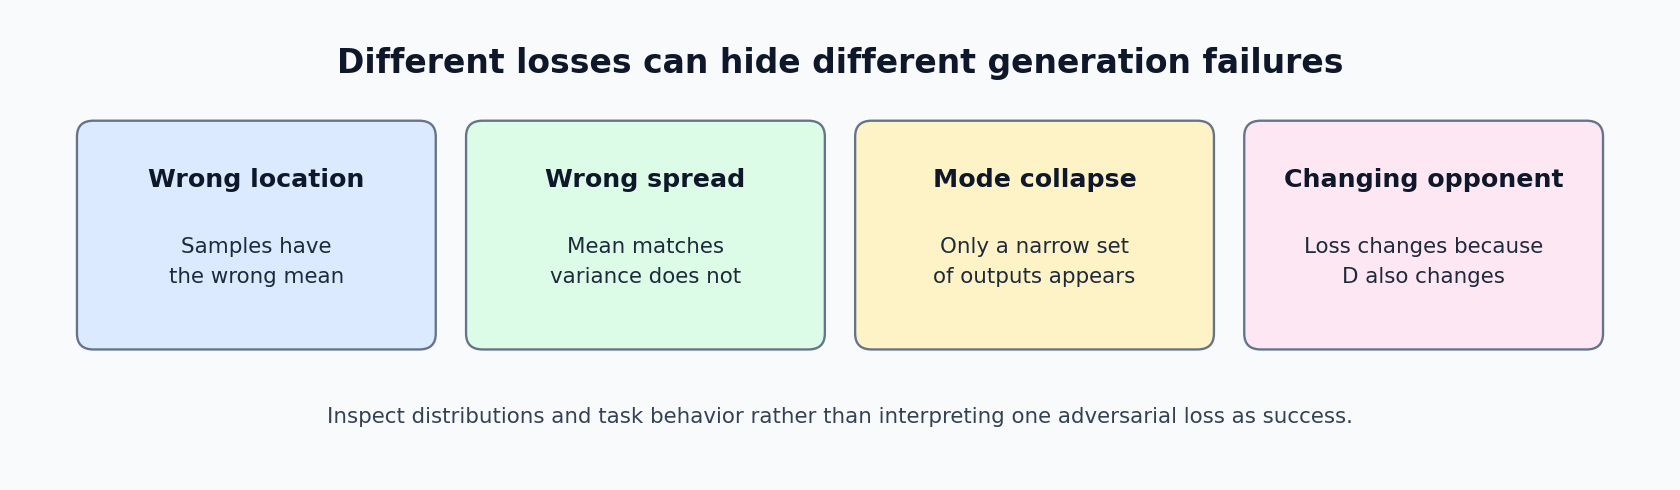

For this target, mean two and variance one are important first checks. A generator returning constant two has the correct mean but zero variance, so it fails to represent the target's variation.

| Generator behavior | Mean | Variance | Assessment |
| --- | --- | --- | --- |
| Constant two | 2 | 0 | Collapsed spread |
| Gaussian mean two, standard deviation 0.2 | 2 | 0.04 | Too narrow |
| Gaussian mean one, standard deviation one | 1 | 1 | Wrong location |
| Target Gaussian | 2 | 1 | Reference moments and shape |

For a multi-component target, **mode collapse** can mean generating only one regime or a narrow subset of plausible outputs. A discriminator may expose the missing variety, but a training run can still settle into poor or oscillating behavior.

Histograms, quantiles, and subgroup coverage can reveal failures that a mean misses. Even matching mean and variance is not sufficient to establish the full distribution, as the mixture example in lesson 37 demonstrated.


## Read adversarial losses as changing measurements

A generator's loss can rise because the discriminator improves, even if generated samples also improve. It can fall because the discriminator weakens, even if samples remain poor. This makes a monotonic-loss expectation unreliable for the two-player system.

| Observation | Possible investigation |
| --- | --- |
| Discriminator quickly becomes very confident | Generator gradient path and player balance |
| Generator outputs become nearly identical | Variation and mode coverage |
| Losses oscillate | Learning rates, updates, and changing opponents |
| Mean improves, spread shrinks | Whole-distribution behavior |
| Finite losses with poor samples | Objective correctness versus learned quality |

Changing architecture, optimizer, or update ratio is an experiment, not an automatic cure. Keep the target sampling rule and evaluation procedure fixed when testing a particular change.

For numerical checking, control random draws and differentiate the specified loss. For task evaluation, inspect independent real and generated samples rather than interpreting one changing opponent's score as an external quality measure.


## Distinguish conditional generation and alternative objectives

A conditional GAN supplies the condition to both generator and discriminator, for example $G(z,c)$ and $D(x,c)$. The generator must produce samples appropriate to the supplied condition; the discriminator evaluates them in that same context.

If the discriminator is not conditioned while the generator is, matching the aggregate distribution need not establish correct condition-following. Labels, paired examples, and the objective determine which conditional relationship can be learned.

Other adversarial objectives use different score interpretations and regularization. A critic trained with a non-probability objective should not automatically be interpreted as a sigmoid realness probability. The formulas in this lesson specifically describe the classical binary discriminator and the companion's non-saturating generator loss.

| Change | What must be redefined? |
| --- | --- |
| Add conditions | Inputs, paired labels, and conditional evaluation |
| Change critic/discriminator objective | Score meaning and gradients |
| Add regularization | Total loss and reduction |
| Change player-update ratio | Training protocol and comparison budget |

Record the actual objective and computation rather than using the name GAN as if it specified every design choice.


## Evaluate the generated distribution outside the training game

The companion uses a known Gaussian target, so independent real samples and theoretical mean/variance make direct comparisons possible. Assess fresh generated values with sample mean, sample variance, quantiles, and density-shape inspection.

A reported generated mean based on 256 draws has its own Monte Carlo variation. Do not interpret a stored reference value in explanatory text as a newly measured result from another execution. Reproduce and report the actual run when making a numerical performance claim.

For complex data, held-out sample quality, diversity, condition adherence, and training-example similarity may all matter. Choose measures that fit the task and state their limitations. A small chosen gallery cannot establish coverage.

A discriminator output is feedback learned from the current real/fake distinction. It is not automatically a calibrated quality scale that can rank arbitrary samples from other models. Independent evaluation is necessary to interpret generation behavior.


## Diagnose the gradient boundaries

| Mistake | Consequence | Check |
| --- | --- | --- |
| Forget to detach fake samples for D-only training | Unwanted generator gradient path | Graph boundary in discriminator step |
| Detach generated samples for the G step | No generator learning through D | Differentiable fake path |
| Wrap D in no-gradient mode during G update | Cut the useful input derivative | Fixed parameters versus fixed computation |
| Step both optimizers from the wrong loss | Train an unintended game | Objective ownership |
| Treat D loss near a reference value as proof | Confuse weak D with matching distributions | Independent sample checks |

The companion preserves the generator path in its generator step and detaches it in its discriminator step. Its short run is explicitly a mechanics illustration, and the notes do not promote finite loss or one printed mean into a success claim.


## Practice the two objectives and retain the training paths

1. What target label is used for fake samples in the discriminator step? What label is used for the non-saturating generator step?
2. If fake probability is 0.1, what is the non-saturating logit derivative?
3. Why is the discriminator still differentiated through during generator training?
4. Can constant outputs at the target mean represent a nonzero-variance Gaussian?
5. How many parameters are in the companion's generator?

**Answers.** Fake targets are zero for D and one for the non-saturating G objective. The derivative is $0.1-1=-0.9$. The discriminator's input derivative carries the learning signal into the generator even while its parameters are not stepped. Constant outputs have zero variance and fail that target. The generator has 49 parameters.

**Remember:** a GAN alternates two objectives over a shared sample path. Correct gradient boundaries establish the game, while independent distribution checks establish whether its generator learned useful outputs.

Continue with [Diffusion Models](40_Diffusion_Models_Notes.ipynb), which uses a known corruption process to create a denoising target.
